In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

<h1>Data Extraction</h1>

In [2]:
import csv

path = "data/possum.csv"

with open(path, mode="r", encoding="utf-8") as file:
    csv_reader = csv.reader(file)
    header = next(csv_reader)
    rows = list(csv_reader)
df = pd.DataFrame(rows, columns=header)

numeric_cols = ["site", "age", "hdlngth", "skullw", "totlngth", "taill"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(f"Loaded {len(df)} rows. Shape: {df.shape}")

Loaded 104 rows. Shape: (104, 14)


In [ ]:
column_drop = ["case", "site"]

df = df.drop(columns=[col for col in column_drop if col in df.columns])

<h1>Data Analytics</h1>

In [ ]:
df["sex_encoded"] = df["sex"].map({"f": 1, "m": 0})

target_cols = {
    "sex_encoded" : "red",
    "age" : "orange",
    "hdlngth" : "blue"
}
col_names = ["Sex", "Age", "Head Length"]

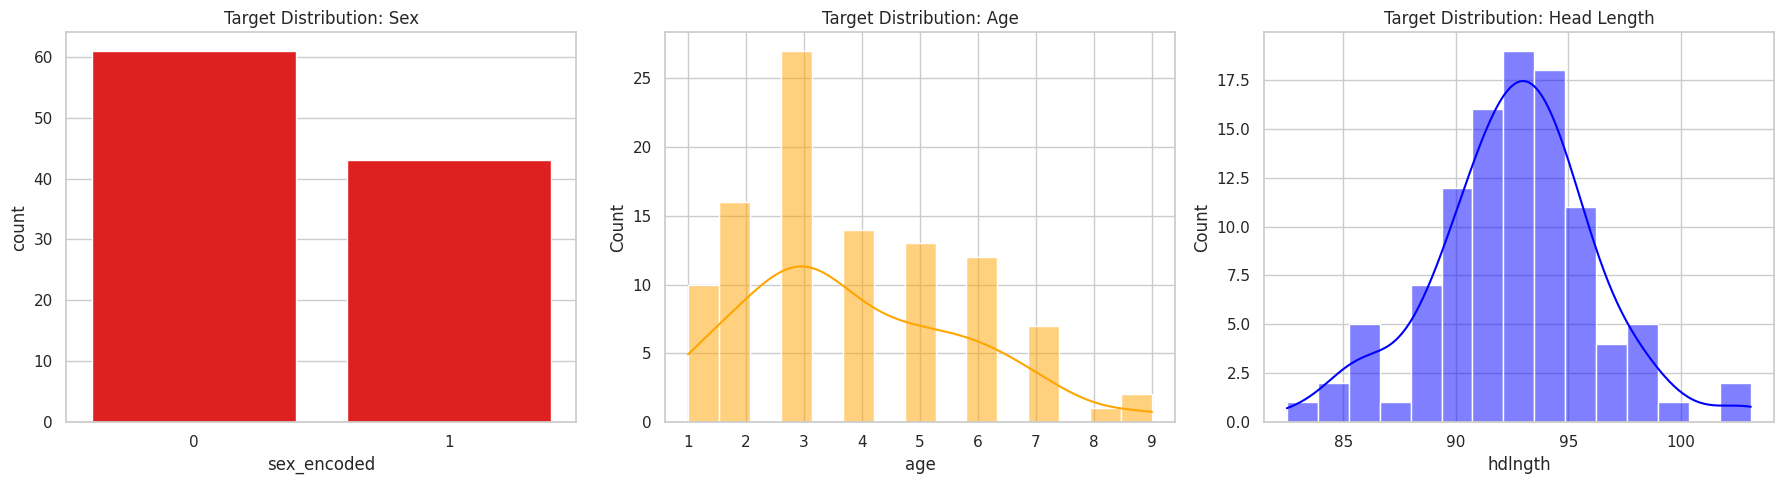

In [24]:
cols_grid = 4
rows_grid = 4

fig, axes = plt.subplots(1, len(target_cols), figsize=(18, 5))

for i, (col_name, col_color) in enumerate(target_cols.items()):
    if col_name not in df.columns:
        continue

    if col_name == "sex_encoded":
        sns.countplot(
            data=df,
            x=col_name,
            color=col_color,
            ax=axes[i]
        )

    else:
        sns.histplot(
            data=df,
            x=col_name,
            bins=15,
            kde=True,
            color=col_color,
            ax=axes[i]
        )

    axes[i].set_title(f"Target Distribution: {col_names[i]}")
    axes[i].set_xlabel(col_name)

plt.tight_layout()
plt.show()

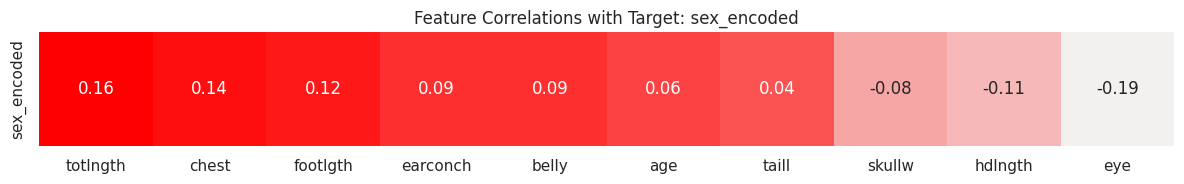

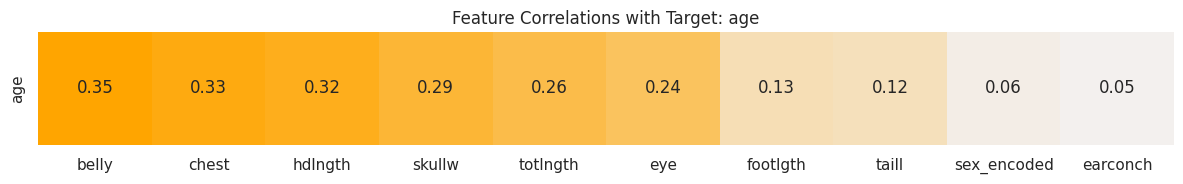

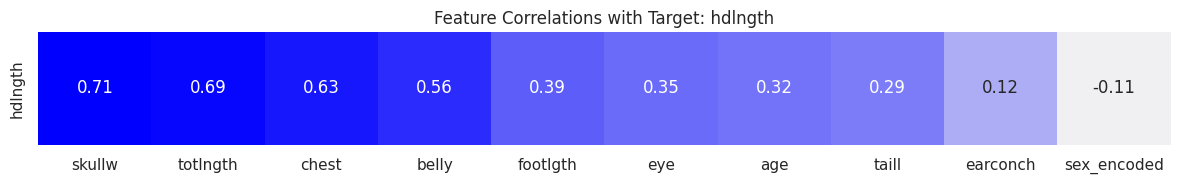

In [ ]:
relation_features = ["skullw", "totlngth", "taill", "footlgth", "earconch", "eye", "chest", "belly"]
active_target = list(target_cols.keys())
all_col = list(set(relation_features + active_target))
col_names = ["Sex", "Age", "Head Length"]

corr_df = df[all_col].apply(pd.to_numeric, errors="coerce")
full_corr_matrix = corr_df.corr()

for i, (col_name, col_color) in enumerate(target_cols.items()):
    if col_name not in full_corr_matrix.columns:
        continue
        
    plt.figure(figsize=(12, 2))

    target_vector = full_corr_matrix[[col_name]].drop(index=col_name).sort_values(by=col_name, ascending=False)

    sns.heatmap(
        target_vector.T, 
        annot=True, 
        fmt=".2f", 
        cmap=sns.light_palette(col_color, as_cmap=True),
        cbar=False
    )
    plt.title(f"Feature Correlations with Target: {col_names[i]}")
    plt.tight_layout()
    plt.show()